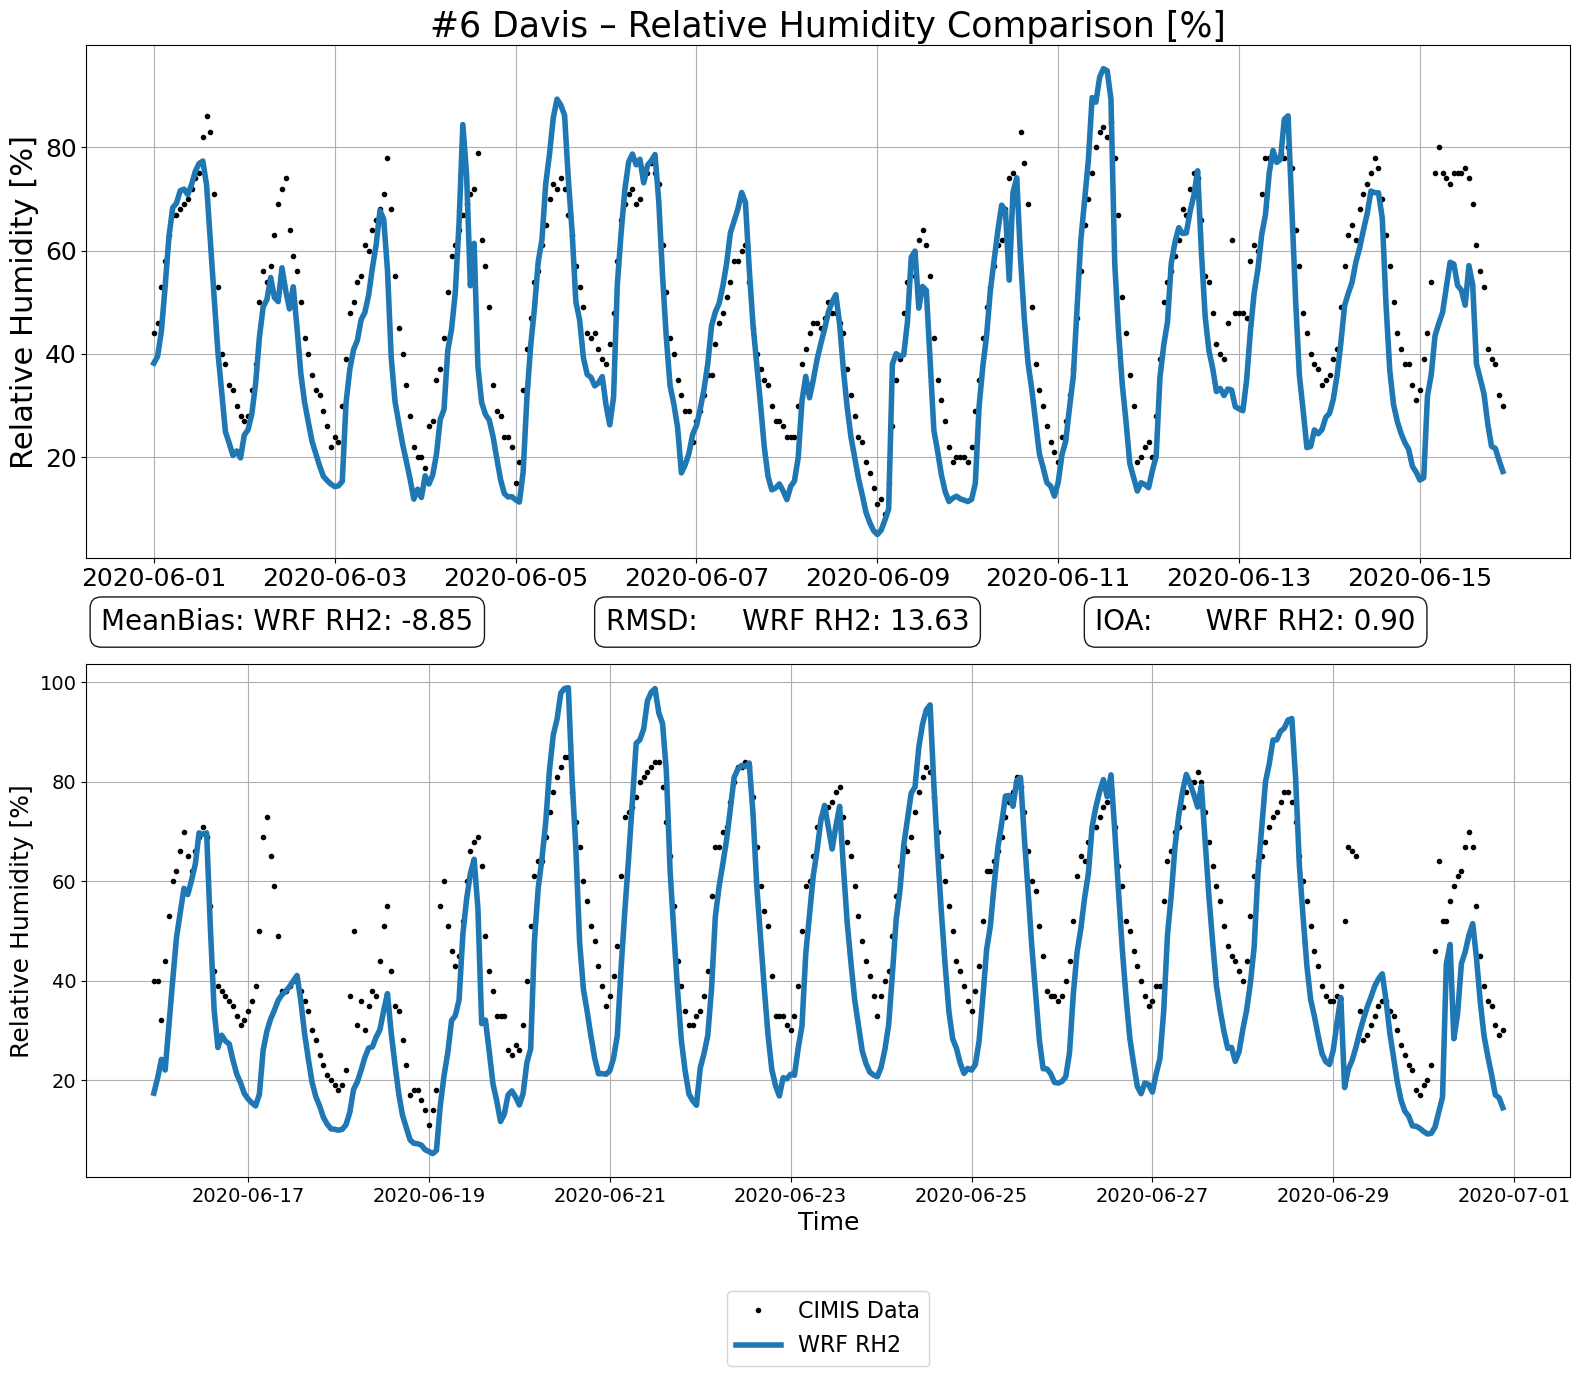

[[-8.853474504417843], [13.626505626597613], [0.8975620663380461]]


In [3]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

# CIMIS Rel Hum (%)
cimis_time = df["Datetime"].values
CIMIS_RH = df["Rel Hum (%)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.535694
lon_point = -121.77636

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF RH2
# ===============================
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if RH2.ndim == 3:
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    RH2_all.extend(RH2_vals)

    time_vals = RH2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

RH2_all = np.array(RH2_all)
wrf_time = pd.to_datetime(np.array(wrf_time))


# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_RH": CIMIS_RH
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_RH"].values,
        merged["RH2"].values
    ],
    "#6 Davis – Relative Humidity Comparison [%]",
    [
        "CIMIS Data",
        "WRF RH2"
    ],
    yaxis="Relative Humidity [%]",
    Show=True
)

print(results)

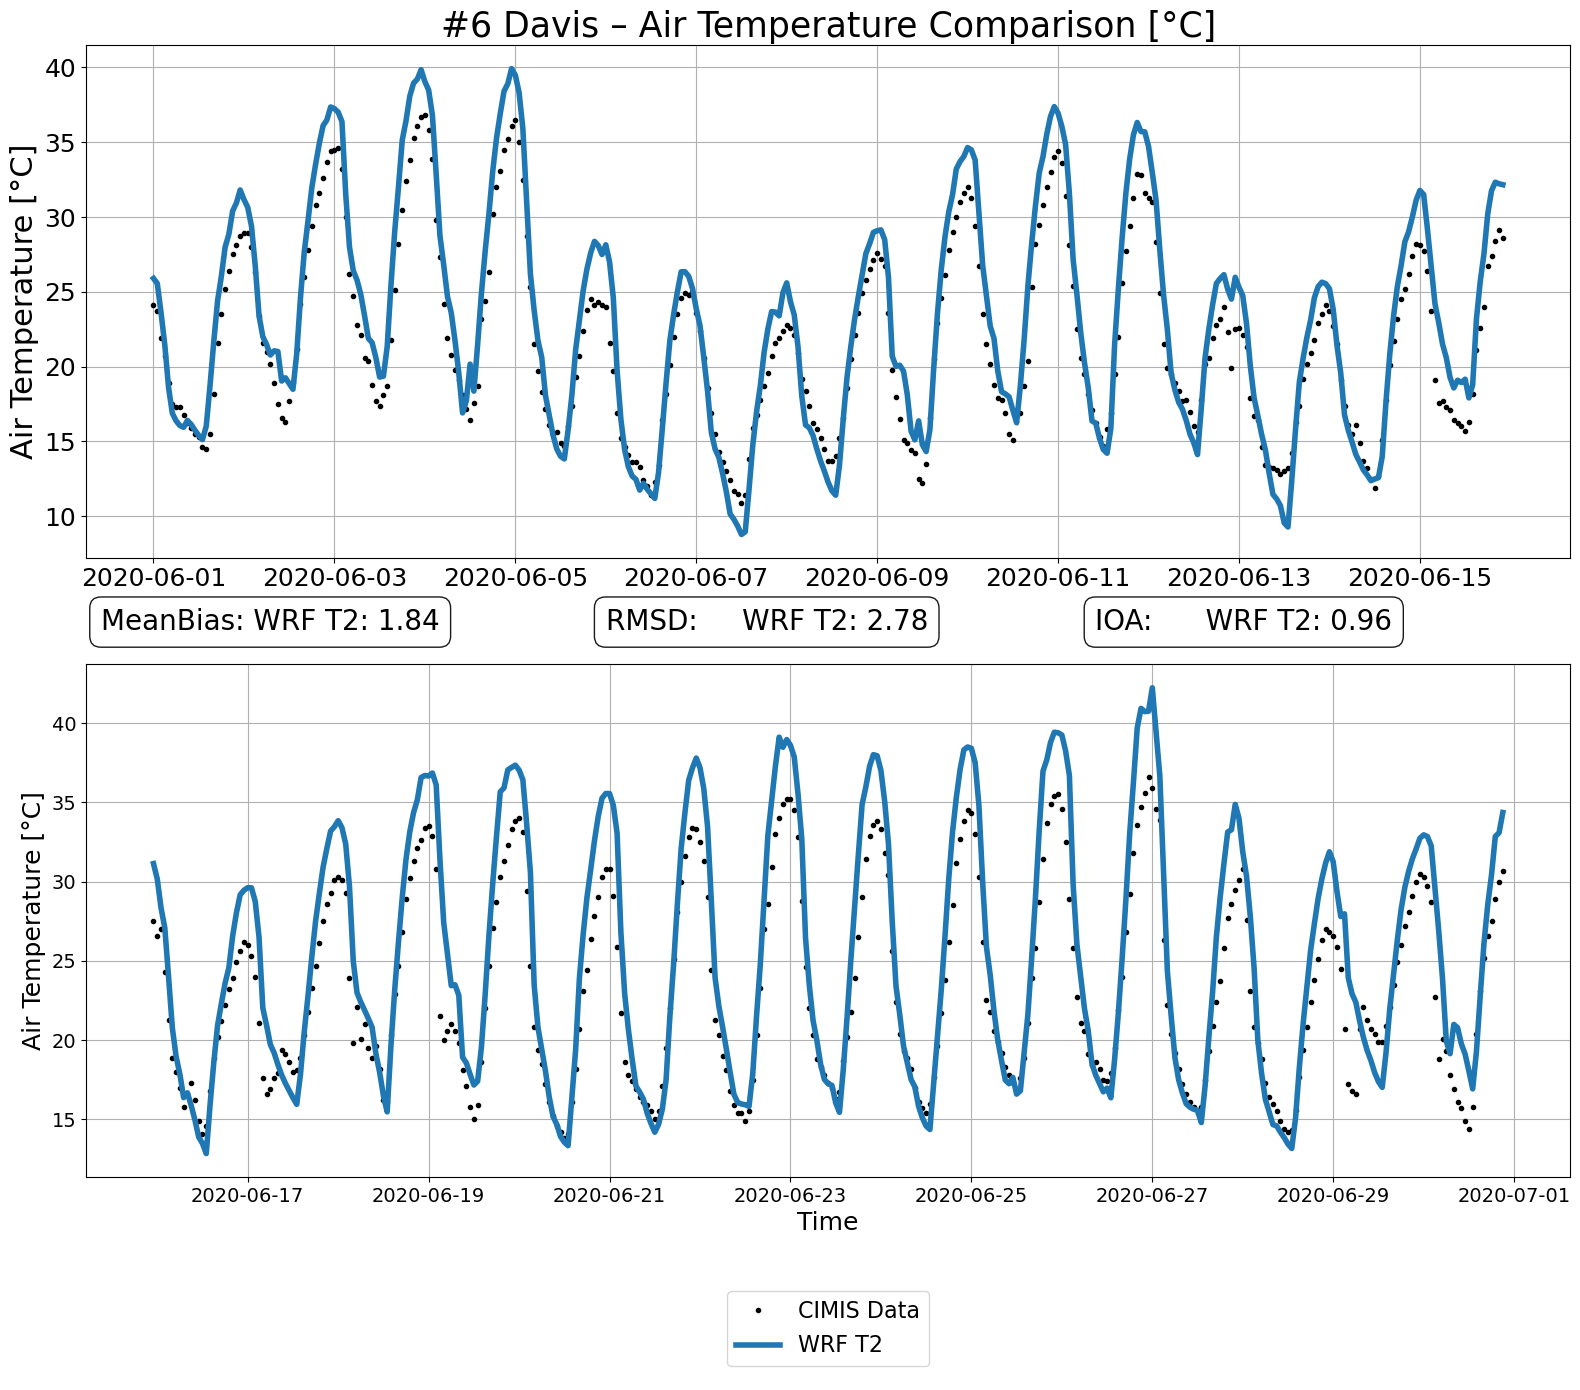

[[1.8391594272189673], [2.784120150345484], [0.9608358929103381]]


In [1]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

# CIMIS Air Temperature (°C)
cimis_time = df["Datetime"].values
CIMIS_Tair_C = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.535694
lon_point = -121.77636

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2
# ===============================
T2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2 = getvar(ds, "T2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals = to_np(T2[:, y_idx, x_idx])
    else:
        T2_vals = [to_np(T2[y_idx, x_idx])]

    T2_all.extend(T2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all = np.array(T2_all)      # Kelvin
wrf_time = pd.to_datetime(np.array(wrf_time))

# Convert WRF temperature to Celsius
T2_C = T2_all - 273.15

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "WRF_Tair_C": T2_C
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_Tair_C"].values,
        merged["WRF_Tair_C"].values
    ],
    "#6 Davis – Air Temperature Comparison [°C]",
    [
        "CIMIS Data",
        "WRF T2"
    ],
    yaxis="Air Temperature [°C]",
    Show=True
)

print(results)

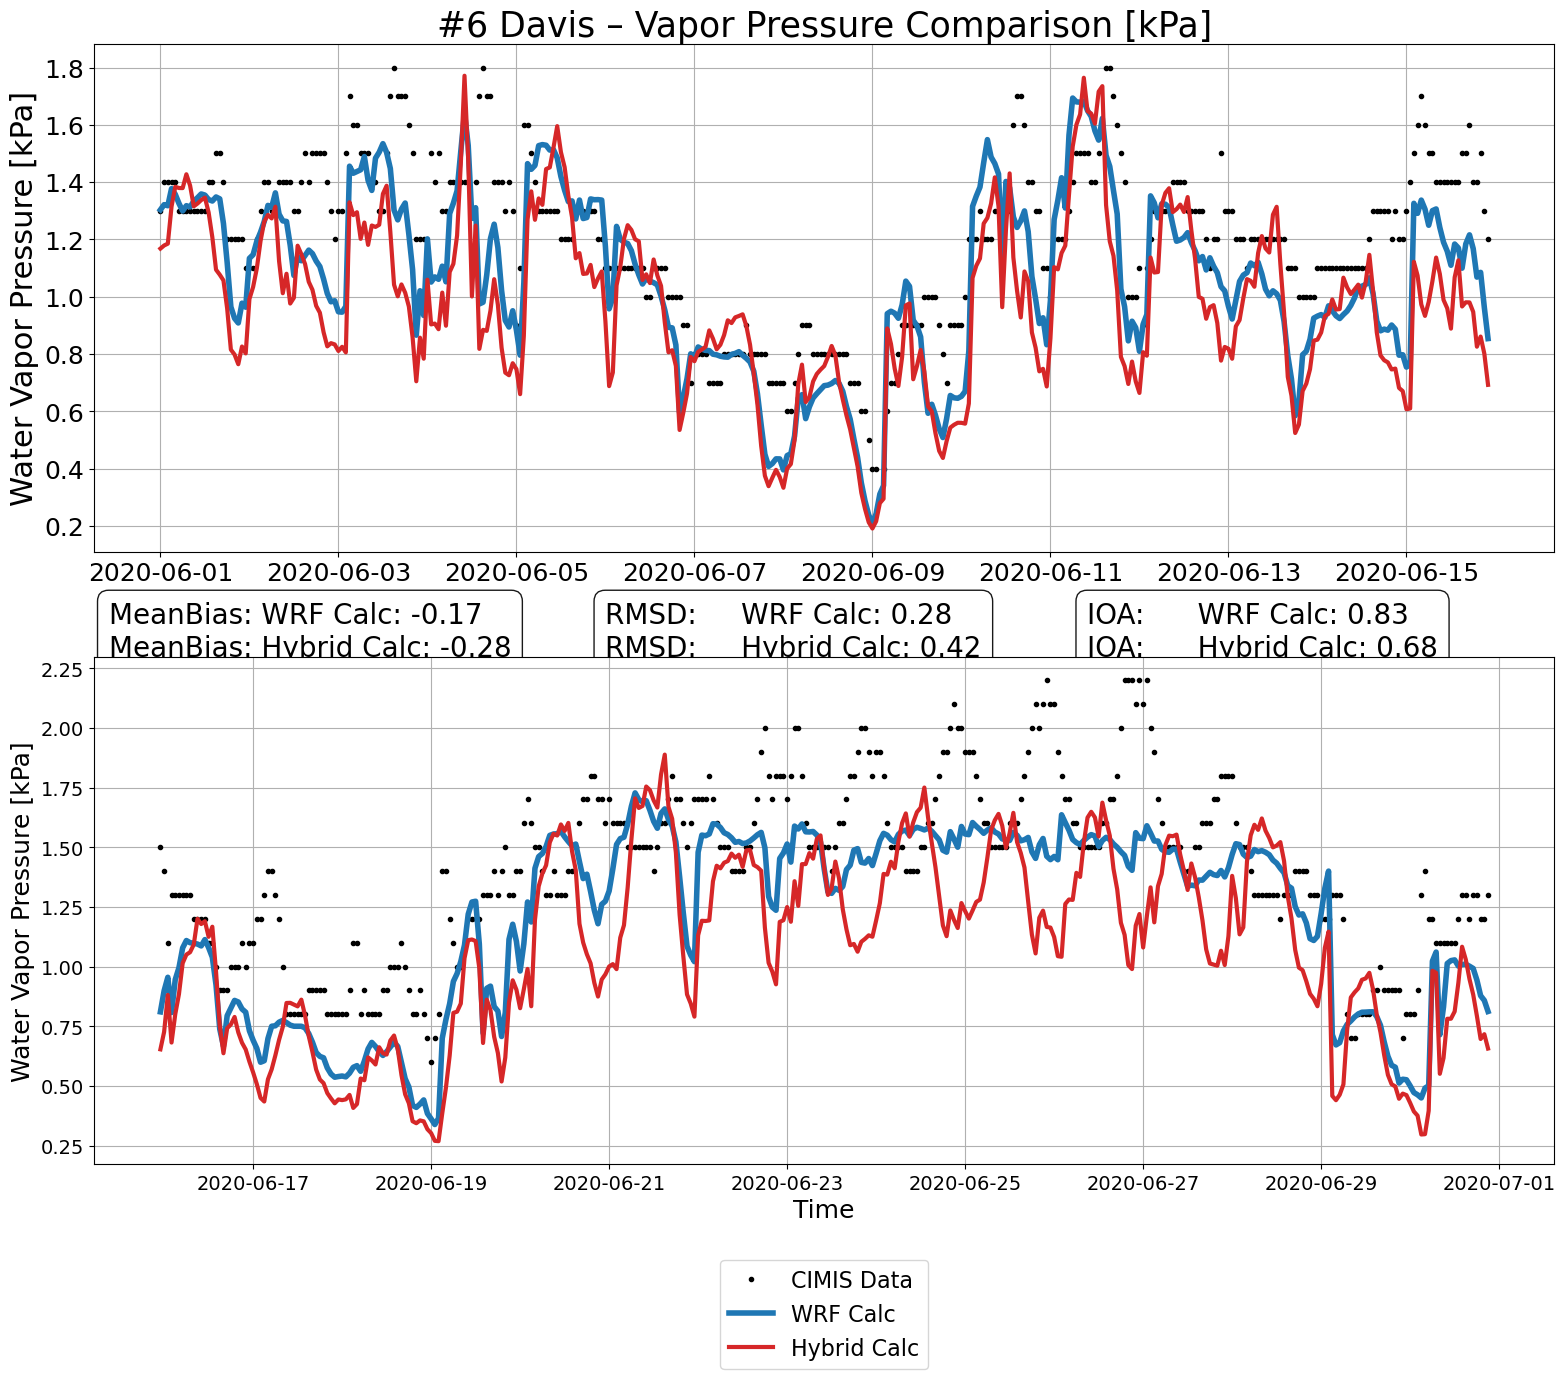

[[-0.17147851241959466, -0.27881666912401265], [0.2820740245852705, 0.41553191818796026], [0.8319967807143294, 0.6753066566946]]


In [1]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

cimis_time = df["Datetime"].values
CIMIS_VapPres = df["Vap Pres (kPa)"].astype(float).values
CIMIS_Tair_C  = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.535694
lon_point = -121.77636

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2 and RH2
# ===============================
T2_all  = []
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2  = getvar(ds, "T2",  timeidx=ALL_TIMES)
    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals  = to_np(T2[:,  y_idx, x_idx])
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        T2_vals  = [to_np(T2[y_idx, x_idx])]
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    T2_all.extend(T2_vals)
    RH2_all.extend(RH2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all   = np.array(T2_all)       # K
RH2_all  = np.array(RH2_all)      # %
wrf_time = pd.to_datetime(np.array(wrf_time))

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "T2": T2_all,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_VapPres": CIMIS_VapPres,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Vapor pressure calculations
# ===============================
L  = 2.5e6
Rv = 461.0

# --- 1) WRF-only (T2 + RH2)
es_wrf = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / merged["T2"].values))
)
e_wrf = (merged["RH2"].values / 100.0) * es_wrf
e_wrf = e_wrf / 10.0  # kPa

# --- 2) Hybrid (CIMIS T + WRF RH2)
Tair_K = merged["CIMIS_Tair_C"].values + 273.15
es_hybrid = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K))
)
e_hybrid = (merged["RH2"].values / 100.0) * es_hybrid
e_hybrid = e_hybrid / 10.0  # kPa

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_VapPres"].values,
        e_wrf,
        e_hybrid
    ],
    "#6 Davis – Vapor Pressure Comparison [kPa]",
    [
        "CIMIS Data",
        "WRF Calc",
        "Hybrid Calc"
    ],
    yaxis="Water Vapor Pressure [kPa]",
    Show=True
)

print(results)

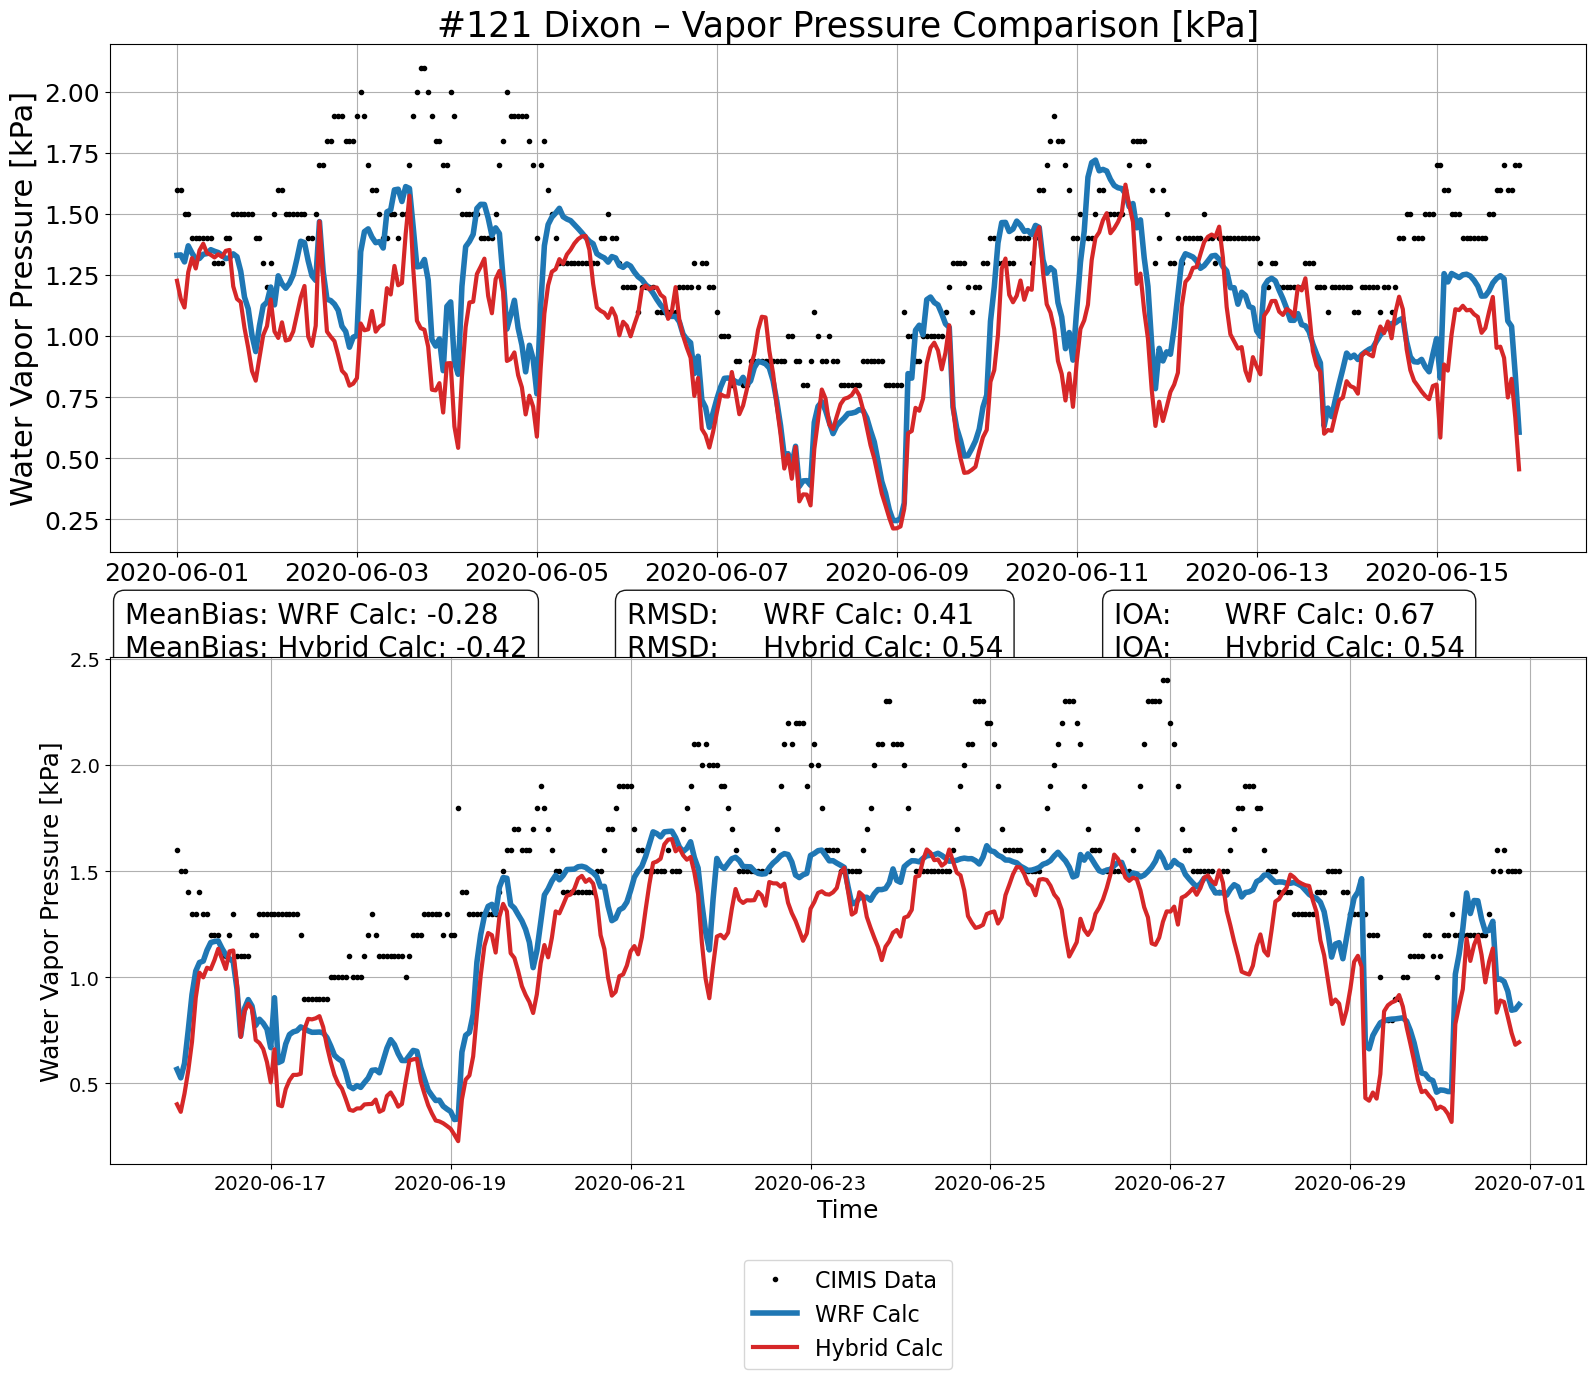

[[-0.27886410887456603, -0.41875051807287333], [0.4087060858958916, 0.543613915664246], [0.6718935346187355, 0.5432925147566288]]


In [2]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/121_Dixon_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

cimis_time = df["Datetime"].values
CIMIS_VapPres = df["Vap Pres (kPa)"].astype(float).values
CIMIS_Tair_C  = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.415564
lon_point = -121.78691

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2 and RH2
# ===============================
T2_all  = []
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2  = getvar(ds, "T2",  timeidx=ALL_TIMES)
    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals  = to_np(T2[:,  y_idx, x_idx])
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        T2_vals  = [to_np(T2[y_idx, x_idx])]
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    T2_all.extend(T2_vals)
    RH2_all.extend(RH2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all   = np.array(T2_all)       # K
RH2_all  = np.array(RH2_all)      # %
wrf_time = pd.to_datetime(np.array(wrf_time))

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "T2": T2_all,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_VapPres": CIMIS_VapPres,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Vapor pressure calculations
# ===============================
L  = 2.5e6
Rv = 461.0

# --- 1) WRF-only (T2 + RH2)
es_wrf = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / merged["T2"].values))
)
e_wrf = (merged["RH2"].values / 100.0) * es_wrf
e_wrf = e_wrf / 10.0  # kPa

# --- 2) Hybrid (CIMIS T + WRF RH2)
Tair_K = merged["CIMIS_Tair_C"].values + 273.15
es_hybrid = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K))
)
e_hybrid = (merged["RH2"].values / 100.0) * es_hybrid
e_hybrid = e_hybrid / 10.0  # kPa

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_VapPres"].values,
        e_wrf,
        e_hybrid
    ],
    "#121 Dixon – Vapor Pressure Comparison [kPa]",
    [
        "CIMIS Data",
        "WRF Calc",
        "Hybrid Calc"
    ],
    yaxis="Water Vapor Pressure [kPa]",
    Show=True
)

print(results)

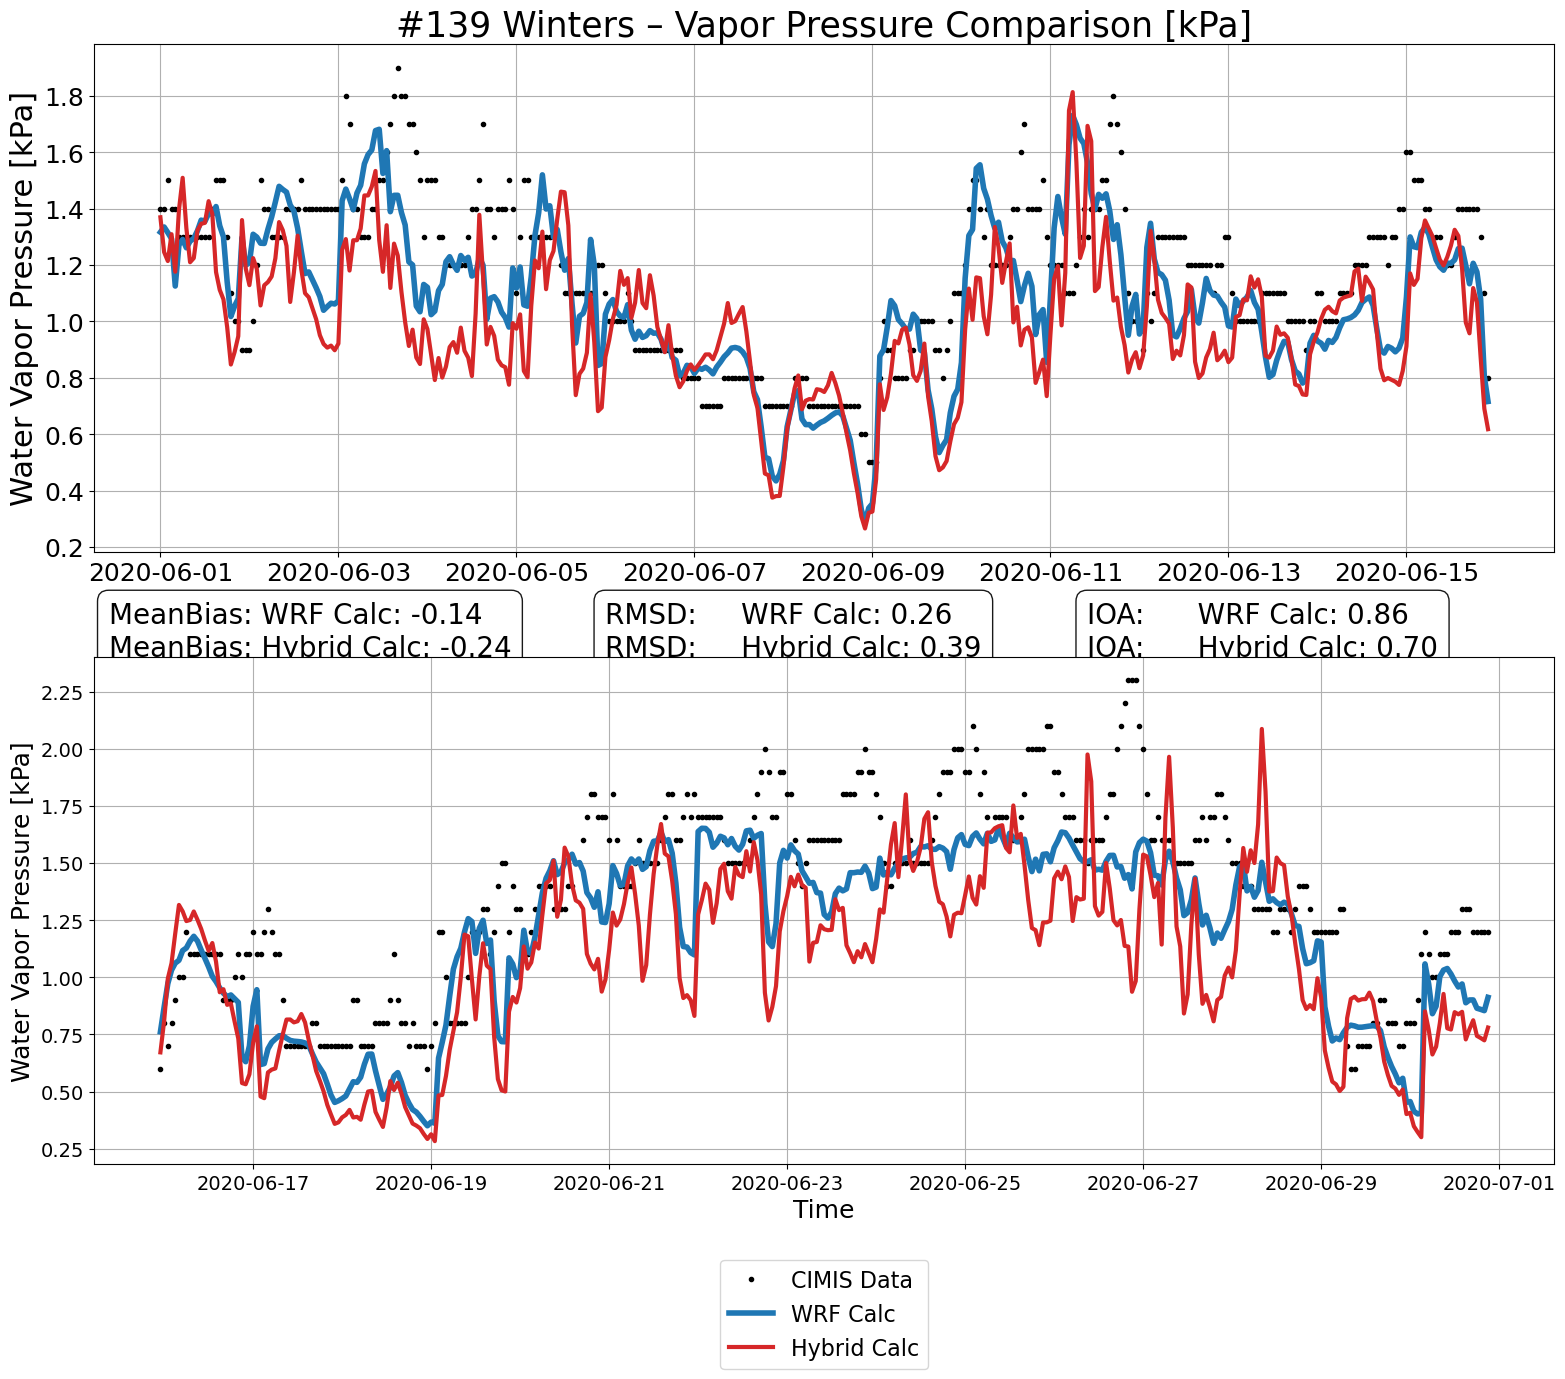

[[-0.1378799143102434, -0.23562495972813022], [0.2599628775800893, 0.38831852775134496], [0.8554297843272968, 0.6989974405972239]]


In [3]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/139_Winters_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

cimis_time = df["Datetime"].values
CIMIS_VapPres = df["Vap Pres (kPa)"].astype(float).values
CIMIS_Tair_C  = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.501258
lon_point = -121.97853

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2 and RH2
# ===============================
T2_all  = []
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2  = getvar(ds, "T2",  timeidx=ALL_TIMES)
    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals  = to_np(T2[:,  y_idx, x_idx])
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        T2_vals  = [to_np(T2[y_idx, x_idx])]
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    T2_all.extend(T2_vals)
    RH2_all.extend(RH2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all   = np.array(T2_all)       # K
RH2_all  = np.array(RH2_all)      # %
wrf_time = pd.to_datetime(np.array(wrf_time))

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "T2": T2_all,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_VapPres": CIMIS_VapPres,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Vapor pressure calculations
# ===============================
L  = 2.5e6
Rv = 461.0

# --- 1) WRF-only (T2 + RH2)
es_wrf = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / merged["T2"].values))
)
e_wrf = (merged["RH2"].values / 100.0) * es_wrf
e_wrf = e_wrf / 10.0  # kPa

# --- 2) Hybrid (CIMIS T + WRF RH2)
Tair_K = merged["CIMIS_Tair_C"].values + 273.15
es_hybrid = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K))
)
e_hybrid = (merged["RH2"].values / 100.0) * es_hybrid
e_hybrid = e_hybrid / 10.0  # kPa

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_VapPres"].values,
        e_wrf,
        e_hybrid
    ],
    "#139 Winters – Vapor Pressure Comparison [kPa]",
    [
        "CIMIS Data",
        "WRF Calc",
        "Hybrid Calc"
    ],
    yaxis="Water Vapor Pressure [kPa]",
    Show=True
)

print(results)

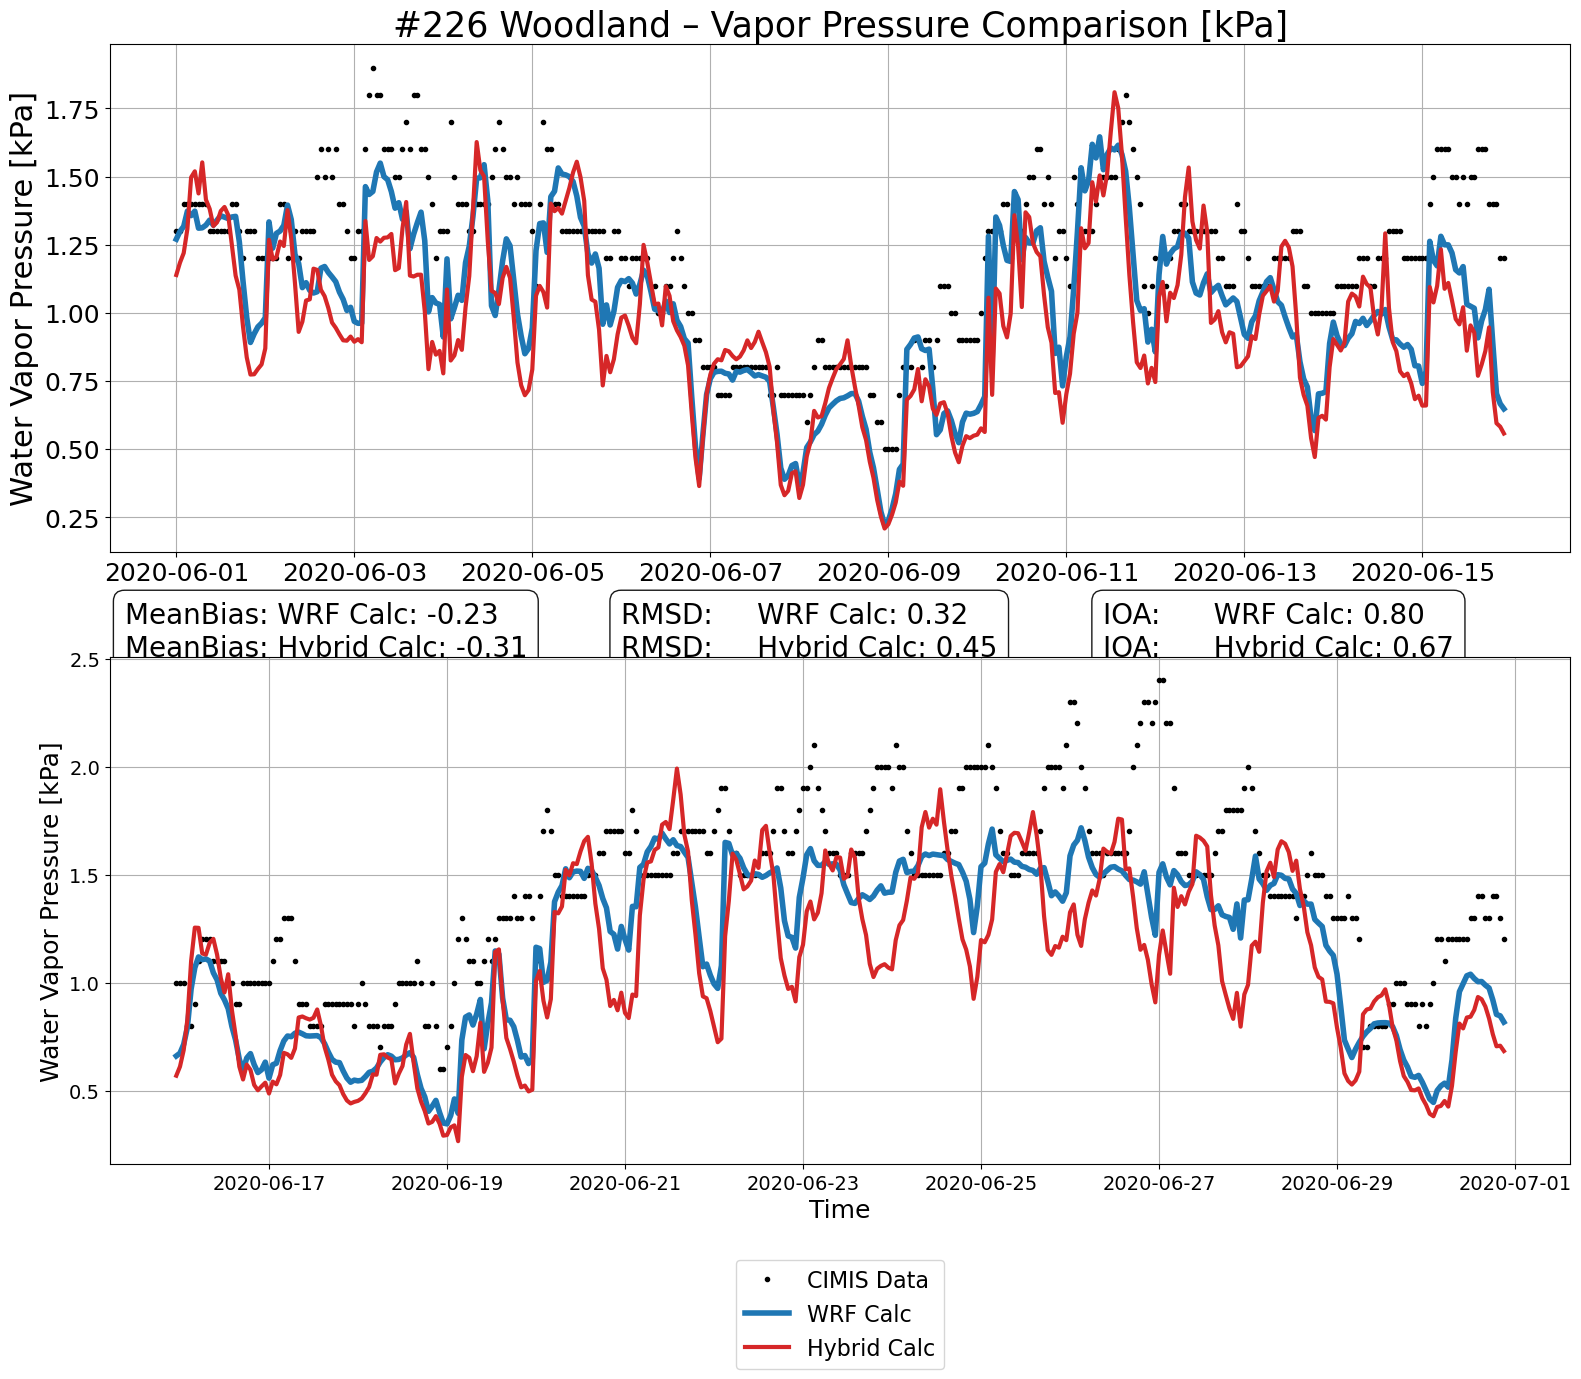

[[-0.2318928697953622, -0.3087350491178787], [0.324025143781919, 0.44719708817674975], [0.8030443433519574, 0.6686352946379441]]


In [4]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/226_Woodland_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

cimis_time = df["Datetime"].values
CIMIS_VapPres = df["Vap Pres (kPa)"].astype(float).values
CIMIS_Tair_C  = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.672722
lon_point = -121.81172

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2 and RH2
# ===============================
T2_all  = []
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2  = getvar(ds, "T2",  timeidx=ALL_TIMES)
    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals  = to_np(T2[:,  y_idx, x_idx])
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        T2_vals  = [to_np(T2[y_idx, x_idx])]
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    T2_all.extend(T2_vals)
    RH2_all.extend(RH2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all   = np.array(T2_all)       # K
RH2_all  = np.array(RH2_all)      # %
wrf_time = pd.to_datetime(np.array(wrf_time))

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "T2": T2_all,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_VapPres": CIMIS_VapPres,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Vapor pressure calculations
# ===============================
L  = 2.5e6
Rv = 461.0

# --- 1) WRF-only (T2 + RH2)
es_wrf = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / merged["T2"].values))
)
e_wrf = (merged["RH2"].values / 100.0) * es_wrf
e_wrf = e_wrf / 10.0  # kPa

# --- 2) Hybrid (CIMIS T + WRF RH2)
Tair_K = merged["CIMIS_Tair_C"].values + 273.15
es_hybrid = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K))
)
e_hybrid = (merged["RH2"].values / 100.0) * es_hybrid
e_hybrid = e_hybrid / 10.0  # kPa

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_VapPres"].values,
        e_wrf,
        e_hybrid
    ],
    "#226 Woodland – Vapor Pressure Comparison [kPa]",
    [
        "CIMIS Data",
        "WRF Calc",
        "Hybrid Calc"
    ],
    yaxis="Water Vapor Pressure [kPa]",
    Show=True
)

print(results)

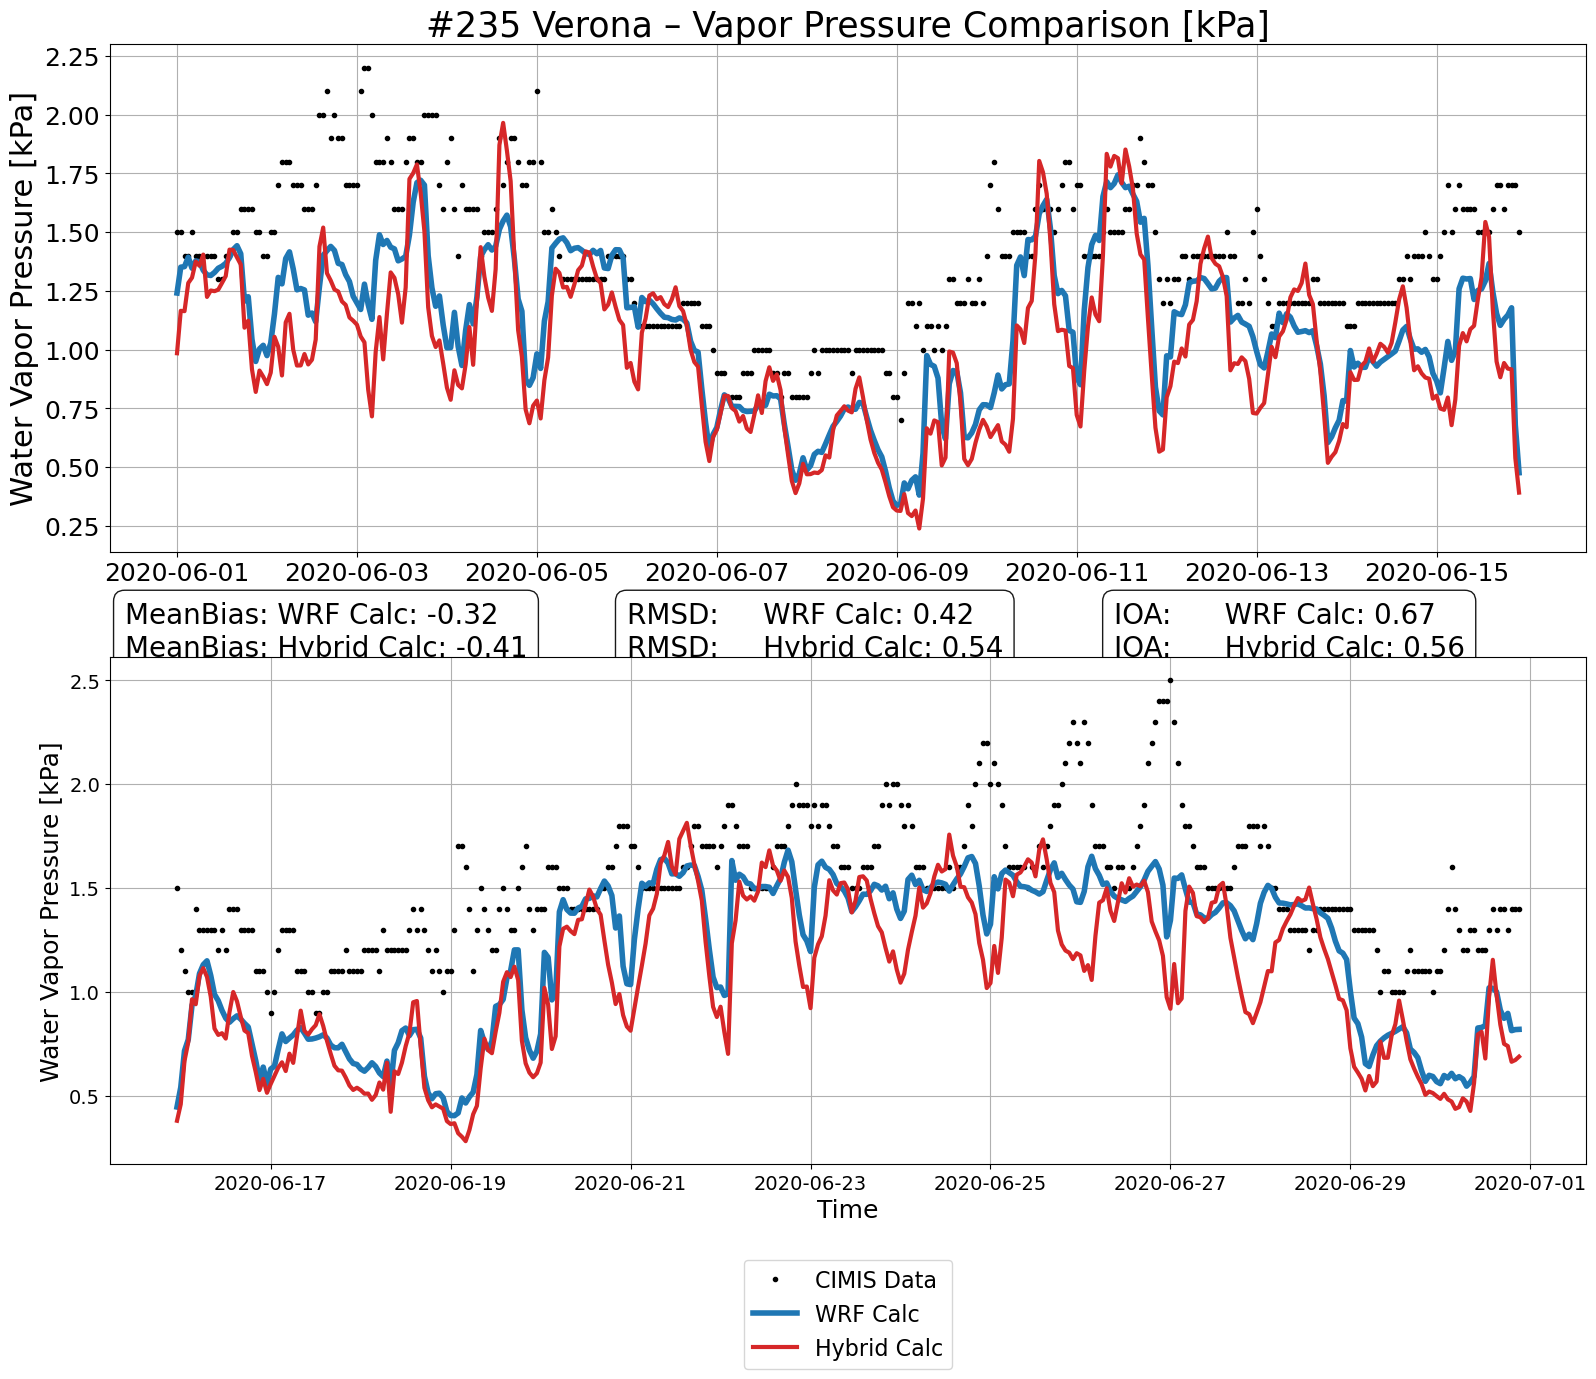

[[-0.316037413113647, -0.413728058877084], [0.4155591780542263, 0.5378418656728969], [0.6713625287568037, 0.5583292289805997]]


In [5]:
# ===============================
# Libraries
# ===============================
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from PyWRFFun import MonthTimeSeries

# ===============================
# CIMIS data
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/235_Verona_hly2020.csv"
df = pd.read_csv(cimis_file)

df["Hour"] = df["Hour (PST)"].astype(str).str.zfill(4)
is_2400 = df["Hour"] == "2400"
df.loc[is_2400, "Hour"] = "0000"

df["Datetime_local"] = pd.to_datetime(
    df["Date"] + " " + df["Hour"].str[:2] + ":00",
    format="%m/%d/%Y %H:%M"
)

df.loc[is_2400, "Datetime_local"] += pd.Timedelta(days=1)

df["Datetime"] = (
    df["Datetime_local"]
    .dt.tz_localize("America/Los_Angeles", ambiguous="NaT", nonexistent="NaT")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

cimis_time = df["Datetime"].values
CIMIS_VapPres = df["Vap Pres (kPa)"].astype(float).values
CIMIS_Tair_C  = df["Air Temp (C)"].astype(float).values

# ===============================
# WRF setup
# ===============================
lat_point = 38.797944
lon_point = -121.61136

wrf_files = sorted(glob(
    "/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"
))

ds_sample = Dataset(wrf_files[0])
x_idx, y_idx = ll_to_xy(ds_sample, lat_point, lon_point, as_int=True)
ds_sample.close()

# ===============================
# Extract WRF T2 and RH2
# ===============================
T2_all  = []
RH2_all = []
wrf_time = []

for filepath in wrf_files:
    ds = Dataset(filepath)

    T2  = getvar(ds, "T2",  timeidx=ALL_TIMES)
    RH2 = getvar(ds, "rh2", timeidx=ALL_TIMES)

    if T2.ndim == 3:
        T2_vals  = to_np(T2[:,  y_idx, x_idx])
        RH2_vals = to_np(RH2[:, y_idx, x_idx])
    else:
        T2_vals  = [to_np(T2[y_idx, x_idx])]
        RH2_vals = [to_np(RH2[y_idx, x_idx])]

    T2_all.extend(T2_vals)
    RH2_all.extend(RH2_vals)

    time_vals = T2.Time.values
    if np.isscalar(time_vals):
        wrf_time.append(time_vals)
    else:
        wrf_time.extend(time_vals)

    ds.close()

T2_all   = np.array(T2_all)       # K
RH2_all  = np.array(RH2_all)      # %
wrf_time = pd.to_datetime(np.array(wrf_time))

# ===============================
# Merge datasets
# ===============================
wrf_df = pd.DataFrame({
    "Datetime": wrf_time,
    "T2": T2_all,
    "RH2": RH2_all
})

cimis_df = pd.DataFrame({
    "Datetime": cimis_time,
    "CIMIS_VapPres": CIMIS_VapPres,
    "CIMIS_Tair_C": CIMIS_Tair_C
})

merged = pd.merge(
    cimis_df,
    wrf_df,
    on="Datetime",
    how="inner"
)

# ===============================
# Vapor pressure calculations
# ===============================
L  = 2.5e6
Rv = 461.0

# --- 1) WRF-only (T2 + RH2)
es_wrf = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / merged["T2"].values))
)
e_wrf = (merged["RH2"].values / 100.0) * es_wrf
e_wrf = e_wrf / 10.0  # kPa

# --- 2) Hybrid (CIMIS T + WRF RH2)
Tair_K = merged["CIMIS_Tair_C"].values + 273.15
es_hybrid = 6.11 * np.exp(
    (L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K))
)
e_hybrid = (merged["RH2"].values / 100.0) * es_hybrid
e_hybrid = e_hybrid / 10.0  # kPa

# ===============================
# Plot & statistics
# ===============================
results = MonthTimeSeries(
    merged["Datetime"].values,
    [
        merged["CIMIS_VapPres"].values,
        e_wrf,
        e_hybrid
    ],
    "#235 Verona – Vapor Pressure Comparison [kPa]",
    [
        "CIMIS Data",
        "WRF Calc",
        "Hybrid Calc"
    ],
    yaxis="Water Vapor Pressure [kPa]",
    Show=True
)

print(results)